In [69]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

scenarios = ['binary-tree', 'multiple-tree', 'JSON', 'code', 'formula', 'paper']
files = [f'./format-results/{scenario}.csv' for scenario in scenarios]

model_list = [
    'Baichuan-7B',
    'Llama-3.1-405B-Instruct',
    'Mistral-7B-Instruct-v0.3',
    'Phi-3.5-mini-instruct',
    'Qwen2.5-72B-Instruct',
    'Yi-1.5-9B-Chat',
    'deepseek-v3',
    'glm-4-9b-chat',
    'gpt-4-turbo',
    'internlm2_5-7b-chat'
]

unify_model_name_map = {
    'Baichuan-7B': 'Baichuan-7B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B-Instruct-v0.3',
    'Phi-3.5-mini-instruct': 'Phi-3.5-mini-instruct',
    'Yi-1.5-9B-Chat': 'Yi-1.5-9B-Chat',
    'deepseek-v3': 'deepseek-v3',
    'llama3.1-405B': 'Llama-3.1-405B-Instruct',
    'Qwen2.5-72B': 'Qwen2.5-72B-Instruct',
    'gpt-4': 'gpt-4-turbo',
    'glm4-9B': 'glm-4-9b-chat',
    'internlm2_5-7b-chat': 'internlm2_5-7b-chat'
}

In [70]:
model_performance = dict()

for file in files:
    df = pd.read_csv(file)
    # unify model name in paper.
    if 'paper' in file:
        df['ModelName'] = df['ModelName'].map(unify_model_name_map)
    # only calculate the best models.
    df = df[df['ModelName'].isin(model_list)]
    # only calculate zeroshot.
    if 'ExampleType' in df.columns:
        df = df[df['ExampleType']=='ZeroShot']
    # skip bullshit cases.
    if 'JSON' in file:
        df = df[df['Mode']!='bullshit']
    
    scenario = os.path.basename(file).rstrip('.csv')
    model_performance[scenario] = df.groupby(["ModelName", "SubTask"])["Accuracy"].agg(accuracy="mean").reset_index()
model_performance['code']

,ModelName,SubTask,accuracy
0,Baichuan-7B,SpaceComplexity,0.5
1,Baichuan-7B,TimeComplexity,0.0
2,Llama-3.1-405B-Instruct,SpaceComplexity,72.0
3,Llama-3.1-405B-Instruct,TimeComplexity,69.0
4,Mistral-7B-Instruct-v0.3,SpaceComplexity,59.0
5,Mistral-7B-Instruct-v0.3,TimeComplexity,58.5
6,Phi-3.5-mini-instruct,SpaceComplexity,64.5
7,Phi-3.5-mini-instruct,TimeComplexity,66.0
8,Qwen2.5-72B-Instruct,SpaceComplexity,70.0
9,Qwen2.5-72B-Instruct,TimeComplexity,68.5


In [71]:
subtask_to_dimension = {
    "add_node": "Structural Modification",
    "all_ancestor": "Local Relationship Awareness",
    "all_children": "Local Relationship Awareness",
    "common_ancestor": "Local Relationship Awareness",
    "isomorphic": "Global Structural Understanding",
    "remove_node": "Structural Modification",
    "node_depth": "Local Relationship Awareness",
    "leaf": "Local Relationship Awareness",
    "root": "Local Relationship Awareness",
    "balance": "Global Structural Understanding",
    "prefix_traversal": "Global Structural Understanding",
    "infix_traversal": "Global Structural Understanding",
    "postfix_traversal": "Global Structural Understanding",
    "traversal_order_verification": "Global Structural Understanding",
    "mirror_tree": "Structural Modification",
    "child_count": "Local Relationship Awareness",
    "level_count": "Global Structural Understanding",
    "node_attribute": "Local Relationship Awareness",
    "level_nodes": "Global Structural Understanding",
    "path_down_to_up": "Local Relationship Awareness",
    "path_up_to_down": "Local Relationship Awareness",
    "shared_ancestor_same_level": "Local Relationship Awareness",
    "shared_ancestor_diff_level": "Local Relationship Awareness",
    "path_between_nodes": "Local Relationship Awareness",
    "calculate": "Analytical Reasoning",
    "convert": "Analytical Reasoning",
    "equivalent": "Analytical Reasoning",
    "SpaceComplexity": "Analytical Reasoning",
    "TimeComplexity": "Analytical Reasoning",
    "contextual_qa": "Textual Reasoning",
    "disordered_section": "Textual Reasoning",
    "outline_extraction": "Textual Reasoning"
}


dimension_performance = list()

for scenario, df in model_performance.items():
    df["Dimension"] = df["SubTask"].map(subtask_to_dimension)
    dimension_performance.append(df.groupby(["ModelName", "Dimension"])["accuracy"].agg(accuracy="mean").reset_index())
dimension_performance = pd.concat(dimension_performance, ignore_index=True)
dimension_performance

,ModelName,Dimension,accuracy
0,Baichuan-7B,Global Structural Understanding,3.861200
1,Baichuan-7B,Structural Modification,0.000000
2,Llama-3.1-405B-Instruct,Global Structural Understanding,51.249833
3,Llama-3.1-405B-Instruct,Structural Modification,36.226667
4,Mistral-7B-Instruct-v0.3,Global Structural Understanding,30.633333
...,...,...,...
92,Qwen2.5-72B-Instruct,Textual Reasoning,53.972500
93,deepseek-v3,Textual Reasoning,42.985000
94,glm-4-9b-chat,Textual Reasoning,37.603333
95,gpt-4-turbo,Textual Reasoning,38.350000


In [72]:
dimension_performance = dimension_performance.groupby(["ModelName", "Dimension"])["accuracy"].agg(accuracy="mean").reset_index()
dimension_performance

,ModelName,Dimension,accuracy
0,Baichuan-7B,Analytical Reasoning,1.048155
1,Baichuan-7B,Global Structural Understanding,1.764289
2,Baichuan-7B,Local Relationship Awareness,3.963181
3,Baichuan-7B,Structural Modification,0.000000
4,Baichuan-7B,Textual Reasoning,0.000000
5,Llama-3.1-405B-Instruct,Analytical Reasoning,67.087716
6,Llama-3.1-405B-Instruct,Global Structural Understanding,65.416611
7,Llama-3.1-405B-Instruct,Local Relationship Awareness,61.585236
8,Llama-3.1-405B-Instruct,Structural Modification,43.424167
9,Llama-3.1-405B-Instruct,Textual Reasoning,16.458333


In [75]:

# from sklearn.preprocessing import MinMaxScaler


# X_scaled = 1 + ((X - X_min) / (X_max - X_min)) * (100 - 1)
pivot_df = dimension_performance.pivot(index='ModelName', columns='Dimension', values='accuracy')
pivot_df
pivot_df = pivot_df.sort_values(by='Analytical Reasoning', ascending=False)

# Function to normalize to the range 1 - 100
# def normalize_to_1_100(df):
#     return 1 + (df - df.min()) / (df.max() - df.min()) * (100 - 1)

# # Normalize the DataFrame
# normalized_df = normalize_to_1_100(pivot_df)
# normalized_df = normalized_df.fillna(0)
# normalized_df

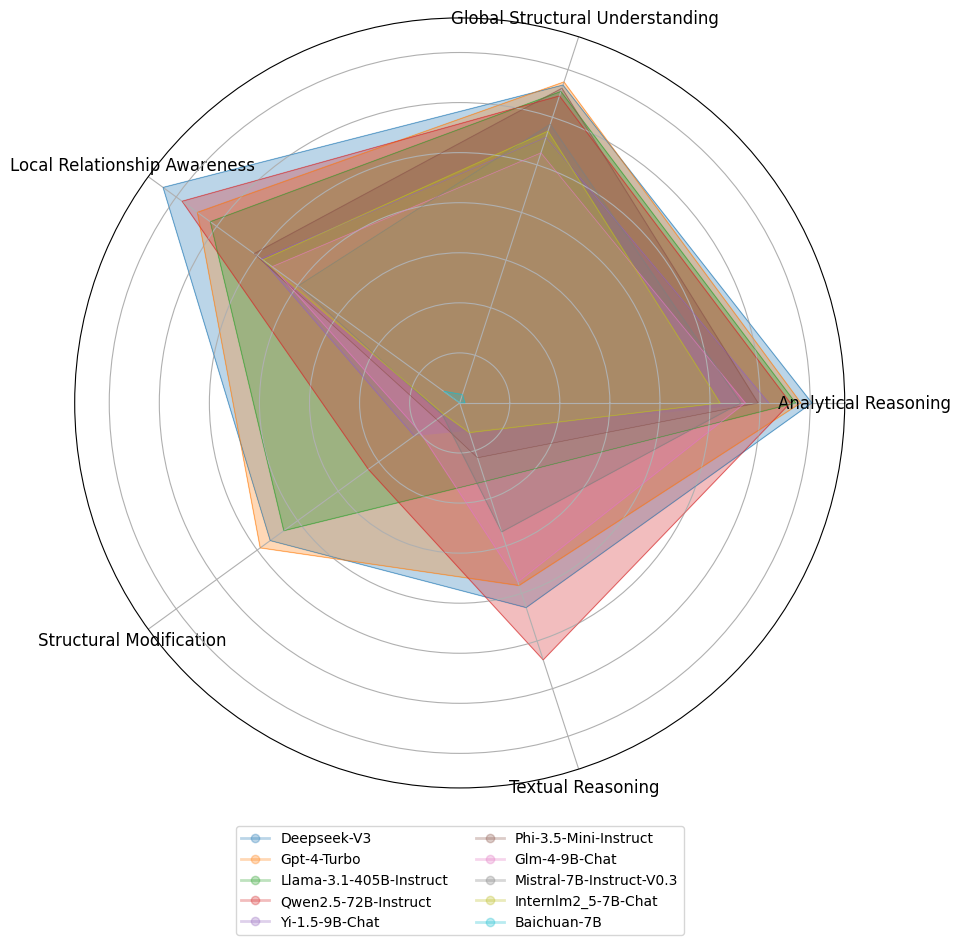

In [80]:
from matplotlib.lines import Line2D

# pivot_df = normalized_df

# Prepare data
categories = pivot_df.columns.tolist()
models = pivot_df.index.tolist()
num_vars = len(categories)

# Define manual colors for each model
colors = ['#1f77b4',  # Blue
          '#ff7f0e',  # Orange
          '#2ca02c',  # Green
          '#d62728',  # Red
          '#9467bd',  # Purple
          '#8c564b',  # Brown
          '#e377c2',  # Pink
          '#7f7f7f',  # Gray
          '#bcbd22',  # Yellow-Green
          '#17becf']  # Cyan

# Calculate angles for the radar chart
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Create the radar plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot each model with filled color and opacity
for model, color in zip(models, colors):
    values = pivot_df.loc[model].tolist()
    values += values[:1]  # Close the circle
    
    # Plot the model's line (no marker)
    ax.plot(angles, values, linewidth=0.3, color=color, label=model.title())
    ax.fill(angles, values, alpha=0.3, color=color)  # Fill the area under the line

# Customize the radar chart
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
# ax.set_xticklabels([])
ax.set_xticklabels(categories, fontsize=12)

# Create custom legend lines dynamically
custom_lines = [
    Line2D([0], [0], color=color, alpha=0.3,linewidth=2, marker='o', markersize=6, label=model.title())
    for model, color in zip(models, colors)
]

# Add the custom legend
ax.legend(
    handles=custom_lines,
    loc='lower center',          # Position the legend at the bottom
    bbox_to_anchor=(0.5, -0.2),  # Adjust placement
    ncol=2,                      # Arrange items in columns
    fontsize=10                  # Adjust font size
)

plt.savefig("radar_chart_label.png", dpi=300, bbox_inches='tight')  # Save as PNG file

# Show the plot
plt.show()